# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [9]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window


## Creamos la sesión de spark

In [10]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [11]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [13]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [14]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [19]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

In [21]:
# --- Cargar los datos procesados para el análisis estático --- 
# Leemos la carpeta donde el streaming está guardando los datos ('resultados/')
# Esto crea un DataFrame estático (df_final) que sí permite hacer .count() y .show()

import time

# (Opcional) Esperamos unos segundos para asegurarnos de que el streaming haya escrito algo
print("Esperando a que el streaming genere datos...")
time.sleep(10) 

try:
    df_final = spark.read.parquet("resultados/")
    print("¡Datos cargados correctamente en df_final!")
except Exception as e:
    print("Aún no hay datos en la carpeta 'resultados/'. Espera un poco más y vuelve a ejecutar esta celda.")

Esperando a que el streaming genere datos...
¡Datos cargados correctamente en df_final!


### Ejercicio 1

In [23]:
print("=== 1. Esquema del DataFrame ===")
df_final.printSchema()

print("\n=== 2. Conteo Total de Filas ===")
total_filas = df_final.count()
print(f"Total de registros (ventanas procesadas): {total_filas}")

print("\n=== 3. Sensores Distintos ===")
num_sensores = df_final.select("sensor_id").distinct().count()
print(f"Cantidad de sensores únicos detectados: {num_sensores}")
print("Lista de sensores:")
df_final.select("sensor_id").distinct().show()

=== 1. Esquema del DataFrame ===
root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)


=== 2. Conteo Total de Filas ===
Total de registros (ventanas procesadas): 430

=== 3. Sensores Distintos ===
Cantidad de sensores únicos detectados: 4
Lista de sensores:
+---------+
|sensor_id|
+---------+
|       S4|
|       S3|
|       S2|
|       S1|
+---------+



### Ejercicio 2

In [24]:
from pyspark.sql.functions import col, min, max, avg

df_transformed = df_final.withColumn("diff_temp_hum", col("avg_temp") - col("avg_humidity"))

print("=== Estadísticas de la nueva columna (Diferencia Temp - Humedad) ===")
df_transformed.select(
    min("diff_temp_hum").alias("Valor_Minimo"),
    max("diff_temp_hum").alias("Valor_Maximo"),
    avg("diff_temp_hum").alias("Valor_Medio")
).show()

=== Estadísticas de la nueva columna (Diferencia Temp - Humedad) ===
+-------------------+------------+-------------------+
|       Valor_Minimo|Valor_Maximo|        Valor_Medio|
+-------------------+------------+-------------------+
|-56.290000000000006|       60.44|0.12728031835925133|
+-------------------+------------+-------------------+



### Ejercicio 3

In [25]:

df_filtered = df_final.filter(
    (col("avg_humidity") > 50) & 
    (col("num_events") > 0) & 
    (col("sensor_id") == "S2")
)


cantidad = df_filtered.count()

print(f"Condiciones aplicadas: Humedad > 50 AND Eventos > 0 AND Sensor == 'S2'")
print(f"Total de registros que cumplen todo a la vez: {cantidad}")


print("--- Muestra de los registros filtrados ---")
df_filtered.show(5)

Condiciones aplicadas: Humedad > 50 AND Eventos > 0 AND Sensor == 'S2'
Total de registros que cumplen todo a la vez: 84
--- Muestra de los registros filtrados ---
+--------------------+---------+------------------+-----------------+-----------------+----------+
|              window|sensor_id|         avg_value|         avg_temp|     avg_humidity|num_events|
+--------------------+---------+------------------+-----------------+-----------------+----------+
|{2026-02-05 19:12...|       S2|39.089999999999996| 64.9657142857143|64.96428571428571|         7|
|{2026-02-05 19:14...|       S2|           26.8825|          58.9025|          56.0275|         8|
|{2026-02-05 19:15...|       S2| 33.54555555555555|54.67888888888889|52.38666666666667|         9|
|{2026-02-05 19:15...|       S2|32.205555555555556|50.94888888888889|51.54999999999999|         9|
|{2026-02-05 19:16...|       S2| 32.42666666666667|53.56166666666667|63.94333333333333|         6|
+--------------------+---------+-------------

### Ejercicio 4

In [26]:
from pyspark.sql.functions import desc, avg, max, count

df_agregado = df_final.groupBy("sensor_id").agg(
    avg("avg_value").alias("Media_Valor"),
    max("avg_temp").alias("Max_Temp"),
    count("window").alias("Total_Ventanas")
)

print("=== Tabla de Estadísticas por Sensor ===")
df_agregado.show()


print("\n1. ¿Qué sensor tiene la mayor media en la variable analizada?")
df_agregado.orderBy(desc("Media_Valor")).limit(1).show()

print("2. ¿Qué sensor presenta la temperatura máxima?")
df_agregado.orderBy(desc("Max_Temp")).limit(1).show()

print("3. ¿Cuántos grupos o ventanas existen por sensor?")
df_agregado.select("sensor_id", "Total_Ventanas").orderBy(desc("Total_Ventanas")).show()

=== Tabla de Estadísticas por Sensor ===
+---------+------------------+--------+--------------+
|sensor_id|       Media_Valor|Max_Temp|Total_Ventanas|
+---------+------------------+--------+--------------+
|       S4|30.861994291973467|   88.96|           108|
|       S3|30.834305145728756|   85.33|           108|
|       S2|29.546429669096337|  77.388|           108|
|       S1|29.068044222548934|  80.955|           106|
+---------+------------------+--------+--------------+


1. ¿Qué sensor tiene la mayor media en la variable analizada?
+---------+------------------+--------+--------------+
|sensor_id|       Media_Valor|Max_Temp|Total_Ventanas|
+---------+------------------+--------+--------------+
|       S4|30.861994291973467|   88.96|           108|
+---------+------------------+--------+--------------+

2. ¿Qué sensor presenta la temperatura máxima?
+---------+------------------+--------+--------------+
|sensor_id|       Media_Valor|Max_Temp|Total_Ventanas|
+---------+-----------

### Ejercicio 5

In [27]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, desc, col

windowSpec = Window.partitionBy("sensor_id").orderBy(desc("avg_value"))
df_ranked = df_final.withColumn("rank", row_number().over(windowSpec))
df_maximos_por_sensor = df_ranked.filter(col("rank") == 1)

print("=== Récord Máximo (avg_value) alcanzado por cada Sensor ===")
df_maximos_por_sensor.select("sensor_id", "avg_value", "window").show(truncate=False)

print("\n--- Respuesta: ¿Qué sensor obtiene el valor máximo global? ---")
df_maximos_por_sensor.orderBy(desc("avg_value")).limit(1).select("sensor_id", "avg_value").show()

=== Récord Máximo (avg_value) alcanzado por cada Sensor ===
+---------+------------------+------------------------------------------+
|sensor_id|avg_value         |window                                    |
+---------+------------------+------------------------------------------+
|S1       |39.8025           |{2026-02-05 21:49:30, 2026-02-05 21:50:00}|
|S2       |40.95             |{2026-02-05 21:42:00, 2026-02-05 21:42:30}|
|S3       |40.739999999999995|{2026-02-05 21:49:30, 2026-02-05 21:50:00}|
|S4       |49.59             |{2026-02-06 01:42:00, 2026-02-06 01:42:30}|
+---------+------------------+------------------------------------------+


--- Respuesta: ¿Qué sensor obtiene el valor máximo global? ---
+---------+---------+
|sensor_id|avg_value|
+---------+---------+
|       S4|    49.59|
+---------+---------+



### Ejercicio 6

In [28]:

datos_info = [
    ("S1", "Laboratorio Quimico", "Alta Precision"),
    ("S2", "Oficina Central", "Estandar"),
    ("S3", "Almacen Exterior", "Resistente"),
    ("S4", "Sala de Servidores", "Critico")
]
columnas_info = ["sensor_id", "ubicacion", "tipo_sensor"]

df_informacion = spark.createDataFrame(datos_info, columnas_info)

print("=== Tabla Auxiliar de Información ===")
df_informacion.show()
df_enrich = df_final.join(df_informacion, on="sensor_id", how="left")
print("\n--- Resultado del Join (Primeros 5 registros) ---")

df_enrich.select("sensor_id", "ubicacion", "tipo_sensor", "avg_value", "avg_temp").show(5, truncate=False)

=== Tabla Auxiliar de Información ===
+---------+-------------------+--------------+
|sensor_id|          ubicacion|   tipo_sensor|
+---------+-------------------+--------------+
|       S1|Laboratorio Quimico|Alta Precision|
|       S2|    Oficina Central|      Estandar|
|       S3|   Almacen Exterior|    Resistente|
|       S4| Sala de Servidores|       Critico|
+---------+-------------------+--------------+


--- Resultado del Join (Primeros 5 registros) ---
+---------+------------------+-----------+------------------+-----------------+
|sensor_id|ubicacion         |tipo_sensor|avg_value         |avg_temp         |
+---------+------------------+-----------+------------------+-----------------+
|S4       |Sala de Servidores|Critico    |34.285000000000004|59.74666666666667|
|S4       |Sala de Servidores|Critico    |33.22857142857143 |71.9542857142857 |
|S3       |Almacen Exterior  |Resistente |36.558            |43.18            |
|S3       |Almacen Exterior  |Resistente |32.8225     

### Ejercicio 7

In [29]:
from pyspark.sql.functions import date_trunc, col, count, avg

df_temporal = df_final.withColumn("tiempo_minuto", date_trunc("minute", col("window.start")))


df_resumen_tiempo = df_temporal.groupBy("tiempo_minuto").agg(
    count("*").alias("Cantidad_Ventanas"),
    avg("avg_humidity").alias("Humedad_Media_Global")
)

print("=== Resumen de Actividad por Minuto ===")
print("Observa cuántas ventanas caen en cada minuto y cómo evoluciona la humedad:")
df_resumen_tiempo.orderBy("tiempo_minuto").show(truncate=False)

=== Resumen de Actividad por Minuto ===
Observa cuántas ventanas caen en cada minuto y cómo evoluciona la humedad:
+-------------------+-----------------+--------------------+
|tiempo_minuto      |Cantidad_Ventanas|Humedad_Media_Global|
+-------------------+-----------------+--------------------+
|2026-02-05 19:12:00|4                |61.53721726190476   |
|2026-02-05 19:13:00|8                |56.58976208513709   |
|2026-02-05 19:14:00|8                |56.88899702380952   |
|2026-02-05 19:15:00|8                |51.25460119047619   |
|2026-02-05 19:16:00|8                |52.20909722222222   |
|2026-02-05 19:17:00|8                |52.16886904761905   |
|2026-02-05 19:18:00|8                |61.28440873015874   |
|2026-02-05 19:19:00|8                |51.76778927669553   |
|2026-02-05 19:20:00|8                |50.14848214285715   |
|2026-02-05 19:21:00|8                |55.337823412698405  |
|2026-02-05 19:22:00|8                |56.84603174603175   |
|2026-02-05 19:23:00|8         

### Ejercicio 8

In [30]:
from pyspark.sql.functions import spark_partition_id
df_repartido = df_final.repartition(4, "sensor_id")
df_analisis_particion = df_repartido.withColumn("numero_particion", spark_partition_id())

print("=== Distribución de registros entre particiones ===")
print("Observa cómo los datos se han acumulado en unas pocas particiones:")


df_analisis_particion.groupBy("numero_particion").count().show()



=== Distribución de registros entre particiones ===
Observa cómo los datos se han acumulado en unas pocas particiones:
+----------------+-----+
|numero_particion|count|
+----------------+-----+
|               0|  108|
|               1|  216|
|               3|  106|
+----------------+-----+



### Ejercicio 9

In [31]:
from pyspark.sql.functions import mean, stddev, col, desc

estadisticas = df_final.select(
    mean("avg_temp").alias("promedio"),
    stddev("avg_temp").alias("desviacion")
).collect()

media_temp = estadisticas[0]["promedio"]
desviacion_temp = estadisticas[0]["desviacion"]

print(f"Temperatura media calculada: {media_temp:.2f}")
print(f"Desviación estándar: {desviacion_temp:.2f}")

limite_superior = media_temp + (2 * desviacion_temp)

print(f"He decidido que cualquier cosa por encima de {limite_superior:.2f} es una ANOMALÍA.")

df_anomalos = df_final.filter(col("avg_temp") > limite_superior)

print("\n--- Respuesta 1: ¿Cuántos registros son anómalos? ---")
cantidad_anomalos = df_anomalos.count()
print(f"He encontrado {cantidad_anomalos} registros raros.")

print("\n--- Respuesta 2: ¿Qué sensor tiene más anomalías? ---")
df_anomalos.groupBy("sensor_id").count().orderBy(desc("count")).show()

Temperatura media calculada: 55.42
Desviación estándar: 8.68
He decidido que cualquier cosa por encima de 72.79 es una ANOMALÍA.

--- Respuesta 1: ¿Cuántos registros son anómalos? ---
He encontrado 12 registros raros.

--- Respuesta 2: ¿Qué sensor tiene más anomalías? ---
+---------+-----+
|sensor_id|count|
+---------+-----+
|       S3|    4|
|       S4|    4|
|       S2|    3|
|       S1|    1|
+---------+-----+



### Ejercicio 10

In [35]:
from pyspark.sql.functions import col, desc

peso_temp = 0.5
peso_hum = 0.3
peso_val = 0.2

df_con_puntuacion = df_final.withColumn("puntuacion_final", 
    (col("avg_temp") * peso_temp) + 
    (col("avg_humidity") * peso_hum) + 
    (col("avg_value") * peso_val)
)

df_ordenado = df_con_puntuacion.orderBy(desc("puntuacion_final"))

mejor_sensor = df_ordenado.first()

print(f"El sensor con la puntuación más alta es: {mejor_sensor['sensor_id']}")
print(f"El valor de su puntuación es: {mejor_sensor['puntuacion_final']:.2f}")
    
print("\nTop 3 sensores:")
df_ordenado.select("sensor_id", "avg_temp", "puntuacion_final").show(3)


El sensor con la puntuación más alta es: S4
El valor de su puntuación es: 72.89

Top 3 sensores:
+---------+--------+-----------------+
|sensor_id|avg_temp| puntuacion_final|
+---------+--------+-----------------+
|       S4|   88.96|72.88799999999999|
|       S4|   75.15|           66.911|
|       S4|   73.57|           66.033|
+---------+--------+-----------------+
only showing top 3 rows



### Ejercicio 11

Convirtiendo a Pandas...


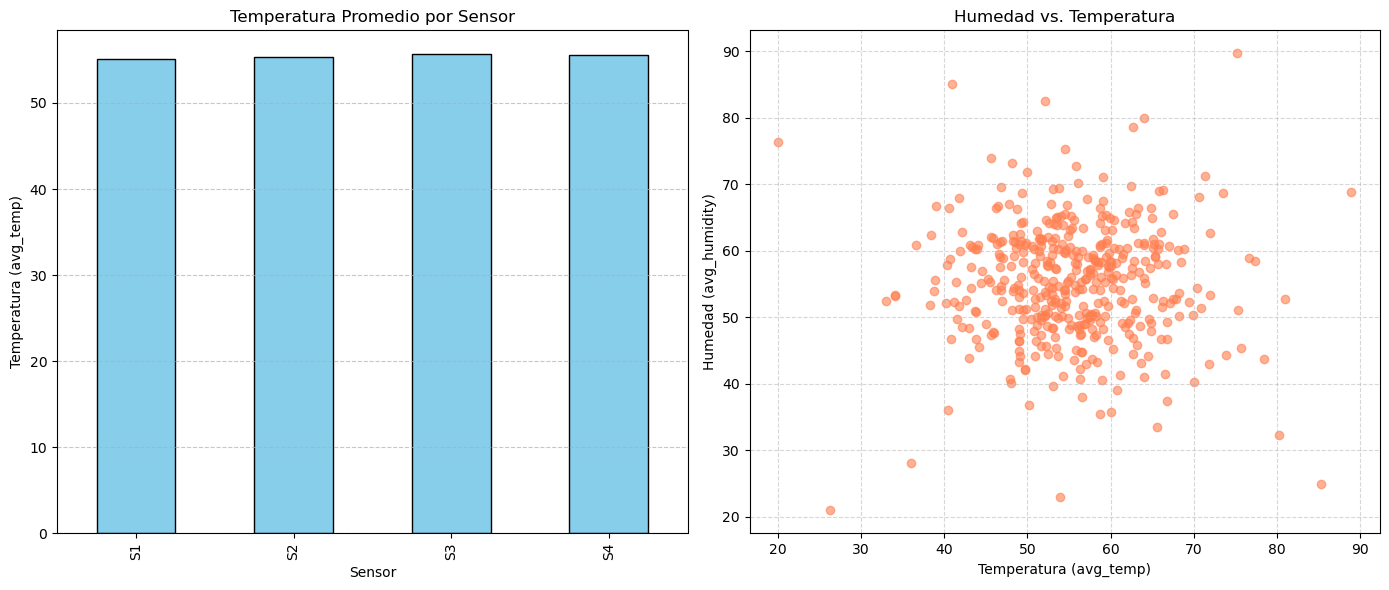

In [36]:

import matplotlib.pyplot as plt
import pandas as pd

print("Convirtiendo a Pandas...")
df_pandas = df_final.toPandas()

plt.figure(figsize=(14, 6))

# --- GRÁFICO 1: Temperatura media por Sensor (Gráfico de Barras) ---
plt.subplot(1, 2, 1) 
df_grouped = df_pandas.groupby('sensor_id')['avg_temp'].mean()
df_grouped.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Temperatura Promedio por Sensor')
plt.xlabel('Sensor')
plt.ylabel('Temperatura (avg_temp)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# --- GRÁFICO 2: Relación Humedad vs. Temperatura (Scatter Plot) ---
plt.subplot(1, 2, 2) # (Posición 2)
plt.scatter(df_pandas['avg_temp'], df_pandas['avg_humidity'], color='coral', alpha=0.6)
plt.title('Humedad vs. Temperatura')
plt.xlabel('Temperatura (avg_temp)')
plt.ylabel('Humedad (avg_humidity)')
plt.grid(True, linestyle='--', alpha=0.5)

# Mostramos todo junto
plt.tight_layout()
plt.show()